# Complexity analysis through time

During our first analysis of the shadowing phenomena over pip environment, we noticed an increasing linear pattern of such phenomena over time (from 2016 to 2025). Starting from this result, we decide to investigate if this linear growing is linked in some way with an increasing of the package complexity (e.g. LOC, cyclomatic complexity, nesting depth, total number of dependencies and the depth of dependency tree)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "../../data/complexity/complexity.csv"

df  = pd.read_csv(DATA_PATH)

df.dropna(inplace=True)

In [3]:
# wrangling dataframe to have it package-wise
df_packages = df.groupby(["year", "package"]).agg(
    lloc = ("lloc", "sum"),
    cyclomatic_complexity = ("cyclomatic_complexity", "sum"),
    max_scope_nesting_level = ("max_scope_nesting_level", "mean"),
    total_dependencies = ("total_dependencies", "max"),
    max_dependencies_depth = ("max_dependencies_depth", "max")
)

df_packages

lloc  cyclomatic_complexity  \
year package                                                    
2016 aioamqp                       944                    425   
     aiohttp-auth                  250                    105   
     ajenti-plugin-traffic          33                     12   
     amonagent                     755                    138   
     android-localization-helper   164                     56   
...                                ...                    ...   
2025 xyzpy                        5100                   2526   
     yanc                          104                     70   
     yapf                         4456                   3047   
     yoco                          171                     68   
     z3                            834                    274   

                                  max_scope_nesting_level  total_dependencies  \
year package                                                                    
2016 aioamqp                                     2.500000                   2   
     aiohttp-auth                                2.833333                  11   
     ajenti-plugin-traffic                       2.333333                  61   
     amonagent                                   1.600000                   3   
     android-localization-helper                 3.000000                   1   
...                                                   ...                 ...   
2025 xyzpy                                       3.000000                  19   
     yanc                                        3.000000                   1   
     yapf                                        2.600000                   2   
     yoco                                        2.000000                   2   
     z3                                          1.857143                   2   

                                  max_dependencies_depth  
year package                                              
2016 aioamqp                                           2  
     aiohttp-auth                                      4  
     ajenti-plugin-traffic                            11  
     amonagent                                         2  
     android-localization-helper                       1  
...                                                  ...  
2025 xyzpy                                             5  
     yanc                                              1  
     yapf                                              2  
     yoco                                              2  
     z3                                                2  

[4131 rows x 5 columns]

In [4]:
def draw_complexity_stats(data, x_col, y_col, x_label, y_label, title, y_log=False):
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=data, x=x_col, y=y_col)
    sns.set_style("white")

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    if y_log:
        plt.yscale("log")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

df_packages_plot = df_packages.reset_index() # reset the index to be able to plot it easily using year as x-axis

In [5]:
df_packages_plot.groupby("year").size().reset_index(name="count")

,year,count
0,2016,388
1,2017,401
2,2018,390
3,2019,418
4,2020,410
5,2021,409
6,2022,411
7,2023,421
8,2024,427
9,2025,456


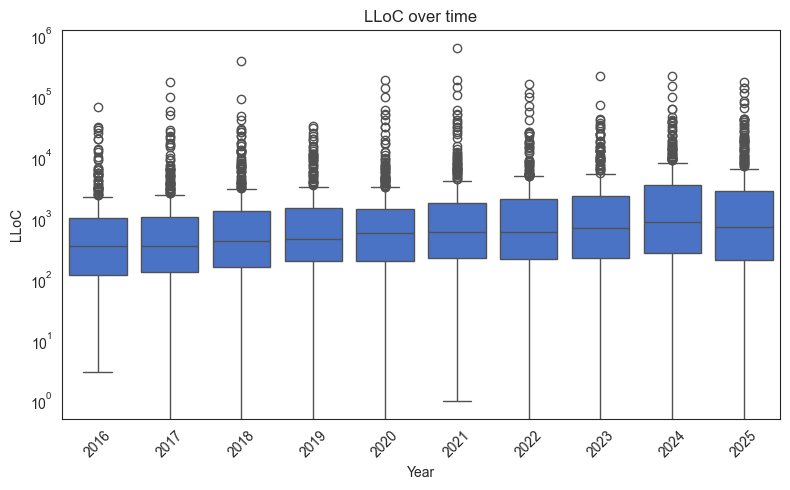

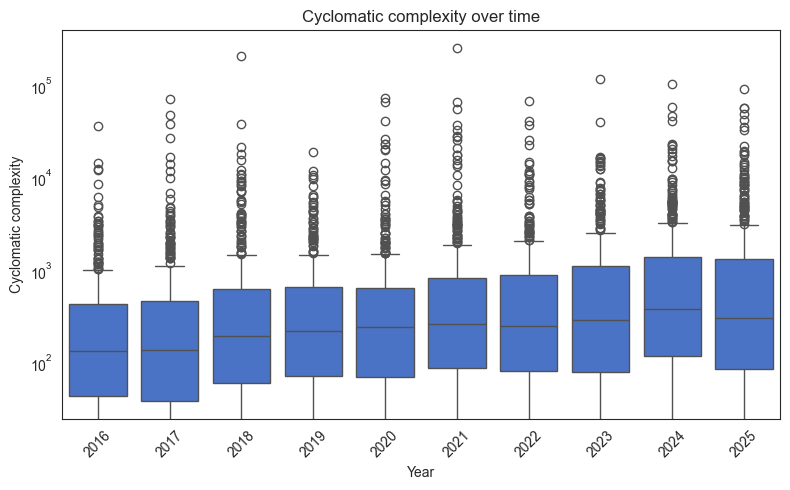

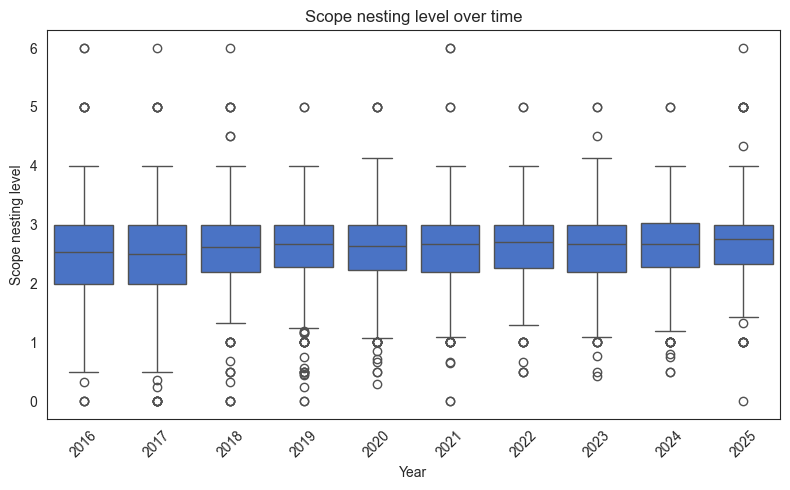

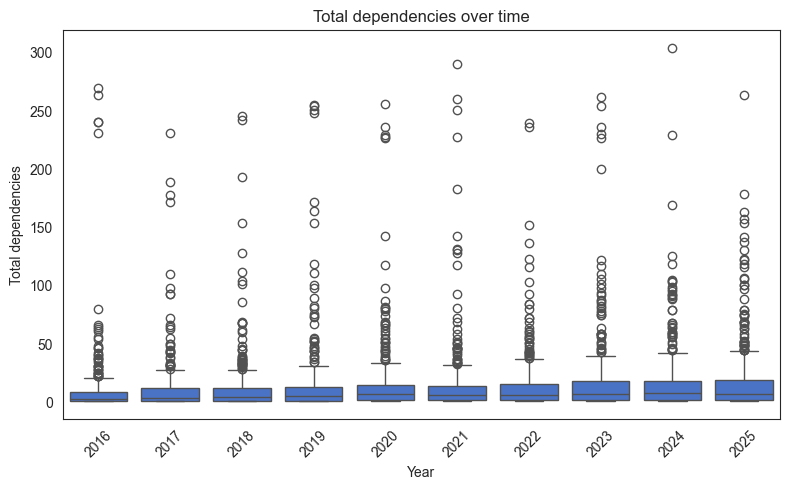

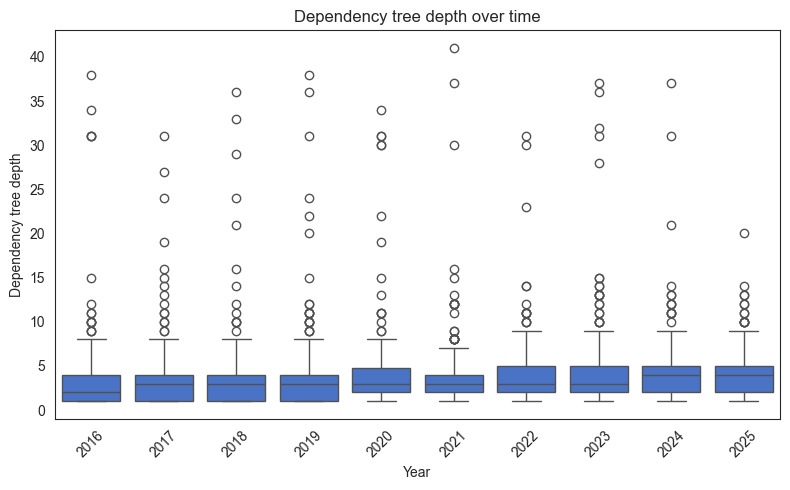

In [7]:
draw_complexity_stats(df_packages_plot, "year", "lloc", "Year", "LLoC", "LLoC over time", y_log=True)
draw_complexity_stats(df_packages_plot, "year", "cyclomatic_complexity", "Year", "Cyclomatic complexity", "Cyclomatic complexity over time", y_log=True)
draw_complexity_stats(df_packages_plot, "year", "max_scope_nesting_level", "Year", "Scope nesting level", "Scope nesting level over time")
draw_complexity_stats(df_packages_plot, "year", "total_dependencies", "Year", "Total dependencies", "Total dependencies over time")
draw_complexity_stats(df_packages_plot, "year", "max_dependencies_depth", "Year", "Dependency tree depth", "Dependency tree depth over time")